In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [2]:
output_folder = "../PhysiCell/results/custom_stochastic_cell_cycle/cell_volumes.csv"
pc_dt = 30.0

pc_df = pd.read_csv(output_folder, float_precision='round_trip', usecols=['id', "dt", "current_phase",'elapsed_time_in_phase'])
pc_df.replace({"current_phase":{4.0: "G0/G1", 10.0: "S", 12.0: "G2", 13.0: "M"}}, inplace=True)
pc_df.rename(columns={'id':'cell_id','current_phase':'phase'}, inplace=True)
pc_phase_times = pc_df.groupby(['cell_id', 'elapsed_time_in_phase'])['dt'].sum()

In [3]:
pc_df['phase_shift'] = pc_df['phase'] != pc_df.groupby('cell_id')['phase'].shift(1)
pc_df['phase_visit'] = pc_df.groupby('cell_id')['phase_shift'].cumsum()
phase_durations = (
    pc_df.groupby(['cell_id', 'phase', 'phase_visit'])
    .agg(start_time=('dt', 'first'), end_time=('dt', 'last'))
    .reset_index()
)
phase_durations['duration'] = phase_durations['end_time'] - phase_durations['start_time']
pc_phases= phase_durations.groupby(['cell_id', 'phase'])['duration'].sum().reset_index()
pc_phases['tool']= 'PhysiCell'
pc_phases['duration'] = pc_phases['duration'] / 60

LOADS CHASTE DATA

In [4]:
output_folder = "../Chaste/unit_test_cellcycle/results/cellcycle_fixed.dat"
ch_dt = 0.1
ch_df = pd.DataFrame(columns=["dt","cell_id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'cell_id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()
            df2['current_phase'] = df2['current_phase'].replace({'G1': 'G0/G1'})

            ch_df =pd.concat([ch_df,df2],ignore_index=True)


In [5]:
results = []

for cell_id, group in ch_df.groupby("cell_id"):
    group = group.sort_values("dt").reset_index(drop=True)
    
    last_phase = None
    start_time = None

    for i, row in group.iterrows():
        current_phase = row["current_phase"]
        current_time = row["dt"]
        
        if last_phase is None:
            # Initial phase
            last_phase = current_phase
            start_time = current_time
            continue

        if current_phase != last_phase:
            # Phase change detected
            duration = current_time - start_time
            results.append({
                "cell_id": cell_id,
                "phase": last_phase,
                "start_time": start_time,
                "end_time": current_time,
                "duration": duration
            })
            # Start new phase
            last_phase = current_phase
            start_time = current_time

    # Final stretch
    if start_time is not None and start_time != current_time:
        duration = current_time - start_time
        results.append({
            "cell_id": cell_id,
            "phase": last_phase,
            "start_time": start_time,
            "end_time": current_time,
            "duration": duration,
            'tool' : 'Chaste'
        })

# Convert to DataFrame
phase_durations_df2 = pd.DataFrame(results)
ch_phases = phase_durations_df2.groupby(['cell_id', 'phase'])['duration'].sum().reset_index()
ch_phases['tool'] = 'Chaste'


In [6]:
output_folder = "../Biodynamo/unit_test_cellcycle_stoch/new_results/output/"
cell_indices = [0, 2, 3, 4]
bd_dt = 0.01

phase_map = {1: "G0/G1", 2: "S", 3: "G2", 4: "M"}
all_cells = []

for idx in cell_indices:
    fname = os.path.join(output_folder, f'cell-{idx}.csv')
    df = pd.read_csv(fname, names=['timestep', 'volume', 'current_phase', 'Age'], header=None)
    df = df[df.current_phase != 0]  # skip unknowns
    df["cell_id"] = idx
    df["dt"] = bd_dt
    df = df.sort_values(by='timestep').reset_index(drop=True)
    all_cells.append(df)

bd_df = pd.concat(all_cells, ignore_index=True)
bd_df['current_phase'] = bd_df['current_phase'].replace(phase_map)

In [7]:
results = []

for cell_id, group in bd_df.groupby("cell_id"):
    group = group.sort_values("timestep").reset_index(drop=True)

    last_phase = None
    start_time = None

    for i, row in group.iterrows():
        current_phase = row["current_phase"]
        current_time = row["timestep"]

        if last_phase is None:
            last_phase = current_phase
            start_time = current_time
            continue

        if current_phase != last_phase:
            duration = current_time - start_time
            results.append({
                "cell_id": cell_id,
                "phase": last_phase,
                "start_time": start_time,
                "end_time": current_time,
                "duration": duration
            })
            last_phase = current_phase
            start_time = current_time

    # Handle final stretch
    if start_time is not None and start_time != current_time:
        duration = current_time - start_time
        results.append({
            "cell_id": cell_id,
            "phase": last_phase,
            "start_time": start_time,
            "end_time": current_time,
            "duration": duration
        })

# Convert to DataFrame
phase_durations_bd = pd.DataFrame(results)

bd_phases = phase_durations_bd.groupby(['cell_id', 'phase'])['duration'].sum().reset_index()
bd_phases['tool'] = "Biodynamo"
bd_phases

,cell_id,phase,duration,tool
0,0,G0/G1,24.76,Biodynamo
1,0,G2,10.00,Biodynamo
2,0,M,0.02,Biodynamo
3,0,S,13.21,Biodynamo
4,2,G0/G1,14.79,Biodynamo
5,2,G2,5.00,Biodynamo
6,2,M,0.01,Biodynamo
7,2,S,8.19,Biodynamo
8,3,G0/G1,7.60,Biodynamo
9,3,S,3.36,Biodynamo


In [8]:
total_phase_times = pd.concat([pc_phases, ch_phases, bd_phases], ignore_index=True)
total_phase_times

,cell_id,phase,duration,tool
0,0.0,G0/G1,21.50,PhysiCell
1,0.0,G2,2.00,PhysiCell
2,0.0,M,5.00,PhysiCell
3,0.0,S,15.00,PhysiCell
4,2.0,G0/G1,11.00,PhysiCell
5,2.0,G2,1.50,PhysiCell
6,2.0,M,2.50,PhysiCell
7,2.0,S,12.00,PhysiCell
8,3.0,G0/G1,5.00,PhysiCell
9,3.0,S,7.00,PhysiCell


/tmp/ipykernel_50356/3314834299.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Tool", bbox_to_anchor=(1.05, 1), loc="upper left")


<Figure size 1600x1200 with 0 Axes>

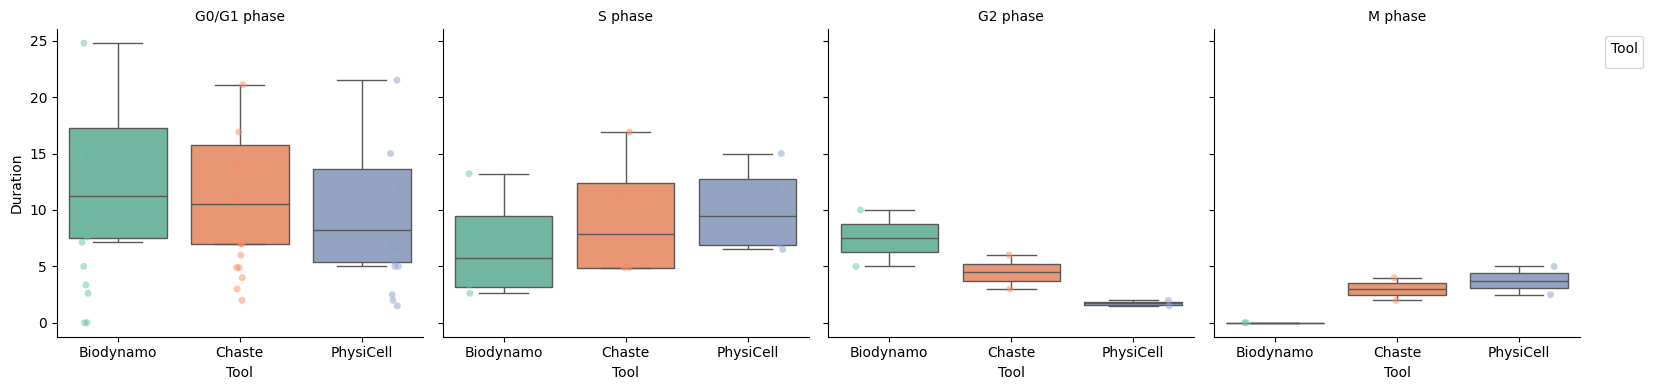

In [9]:
# total_phase_times["phase"] = total_phase_times["phase"].map(phase_map).fillna(df["phase"])

# # Convert 'phase' to category to enforce order
phase_order = ["G0/G1", "S", "G2", "M"]
tool_order = sorted(total_phase_times["tool"].unique())  # or specify manually if needed

total_phase_times["phase"] = pd.Categorical(total_phase_times["phase"], categories=phase_order, ordered=True)
total_phase_times["tool"] = pd.Categorical(total_phase_times["tool"], categories=tool_order, ordered=True)

# Plot
plt.figure(figsize=(16, 12))
g = sns.catplot(
    data=total_phase_times,
    x="tool",
    y="duration",
    col="phase",
    kind="box",
    hue="tool",
    col_order=phase_order,
    palette="Set2",
    height=4,
    aspect=1
)

# Add points on top of the boxplots
sns.stripplot(
    data=total_phase_times,
    x="tool",
    y="duration",
    hue="tool",
    dodge=True,
    alpha=0.5,
    jitter=True,
    ax=g.axes[0][0], palette="Set2"
)
for i, ax in enumerate(g.axes[0][1:], start=1):
    sns.stripplot(
        data=total_phase_times[total_phase_times["phase"] == phase_order[i]],
        x="tool",
        y="duration",
        hue="tool",
        dodge=True,
        alpha=0.5,
        jitter=True,
        ax=ax,
        palette="Set2"
    )

# Cleanup
g.set_titles("{col_name} phase")
g.set_axis_labels("Tool", "Duration")
g.tight_layout()
# g._legend.remove()  # remove duplicate legend
plt.legend(title="Tool", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [10]:
# Sum time spent by each cell in each phase

# plt.figure(figsize=(10, 6))

# # Boxplot of time spent per phase
# sns.boxplot(data=phase_times, x='current_phase', y='time_in_phase', 
#             color='lightblue', showfliers=False)

# # Overlay points (jittered)
# sns.stripplot(data=phase_times, x='current_phase', y='time_in_phase', 
#               color='black', size=4, jitter=0.25, alpha=0.6)

# plt.xlabel("Cell Cycle Phase")
# plt.ylabel("Time Spent in Phase (per cell)")
# plt.title("Distribution of Time Spent in Each Cell Cycle Phase")
# plt.tight_layout()
# phase_times
# plt.show()

In [11]:
# output_folder=("../Tisim/unit_test_cellcycle_stoch/cell cycle stochastic.csv")
# data = pd.read_csv(output_folder, header=0)
# data
# time_steps = data['time (hour)']
# volume_columns = data.columns[1:]  # Assuming all other columns are cell volumes

# average_volumes = data[volume_columns].mean(axis=1, skipna=True)
# initial_total_volume = average_volumes.iloc[0]

# percentage_total_volumes = (average_volumes / initial_total_volume)*100
# # print(percentage_total_volumes)
# # Create a new DataFrame with time steps and percentage of total volumes
# ts_df = pd.DataFrame({
#     'timestep': time_steps,
#     'volumes': percentage_total_volumes
# })
# ts_df


In [12]:
# # Sum time spent by each cell in each phase

# plt.figure(figsize=(10, 6))

# # Boxplot of time spent per phase
# sns.boxplot(data=phase_times_ch, x='current_phase', y='time_in_phase', 
#             color='lightblue', showfliers=False)

# # Overlay points (jittered)
# sns.stripplot(data=phase_times, x='current_phase', y='time_in_phase', 
#               color='black', size=4, jitter=0.25, alpha=0.6)
# plt.show()